In [2]:
from lsst.meas.algorithms import LoadReferenceObjectsConfig, ReferenceObjectLoader
from lsst.daf.butler import Butler, Quantum
from lsst.pipe.base import QuantumContext
from lsst.pipe.tasks.coaddBase import makeSkyInfo
from lsst.sphgeom import IntersectionRegion, Region, Circle, LonLat, Angle, UnitVector3d, UnionRegion
from lsst.sphgeom import HtmPixelization
from lsst.skymap import Index2D

import lsst.geom

import matplotlib.pyplot as plt
import numpy as np

from itertools import product, combinations

In [3]:
def mag_to_radius(mag):
    """Convert GAIA g-band magnitude to radius (in radians).
    """
    mag = np.asarray(mag, dtype=np.float64)
    return np.select(
        [mag <= 11.0, mag <= 14.0],
        np.array([450, 200.0]) * 0.2 * np.pi / (180 * 60 * 60),  # 450 & 200 px
        default=0.0,
    )

Text(0, 0.5, 'Radii [arcmin]')

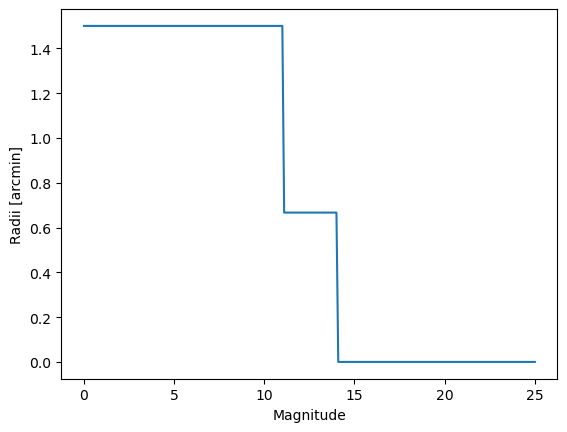

In [12]:
mags = np.linspace(0, 25, 251)
radii = mag_to_radius(mags) * 180 * 60 / np.pi
plt.plot(mags, radii)
plt.xlabel("Magnitude")
plt.ylabel("Radii [arcmin]")

In [10]:
ref_loader_config = LoadReferenceObjectsConfig()

# pixelMargin has to be at least the size of the maximum pixel_radius.
ref_loader_config.pixelMargin = 450  # arbitrary for demo purposes

# AB magnitude from nJy flux: mag = -2.5*log10(flux_nJy) + 31.4
AB_ZP_NJY = 31.4

In [5]:
butler = Butler("dp2_prep", collections=["LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage3"])
skyMap = butler.get("skyMap", skymap="lsst_cells_v2")

In [6]:
tractId = 9813  # COSMOS field

In [7]:
tractInfo = skyMap[tractId]
wcs = tractInfo.getWcs()

# Bounding box for the tract, expanded by pixelMargin on all sides.
bbox = lsst.geom.Box2D(tractInfo.getBBox())
bbox.grow(ref_loader_config.pixelMargin)

tracts = []

# Convert each corner (pixel coords) to sky, then find the tract there.
corners = bbox.getCorners()
for corner in corners:
    coord = wcs.pixelToSky(corner)
    tract = skyMap.findTract(coord)
    tracts.append(tract.getId())

for corner1, corner2 in combinations(corners, 2):
    eval_point = lsst.geom.Point2D(
        0.5 * (corner1.x + corner2.x),
        0.5 * (corner1.y + corner2.y),
    )
    coord = wcs.pixelToSky(eval_point)
    tract = skyMap.findTract(coord)
    tracts.append(tract.getId())
    
print(tracts)

[9571, 9570, 10054, 10056, 9570, 9813, 9814, 9812, 9813, 10055]


In [9]:
assert tractId - 1 in tracts
assert tractId + 1 in tracts
assert len(set(tracts)) >= 8

In [8]:
ref_cat_refs = butler.query_datasets("the_monster_20250219", where=f"skymap='lsst_cells_v2' AND tract IN {tuple(set(tracts))}")
print("Number of reference catalogs (htm7 regions) considered = ", len(ref_cat_refs))

Number of reference catalogs (htm7 regions) considered =  111


In [28]:
%matplotlib inline

from matplotlib.patches import Ellipse, Polygon

def bbox_to_radec(bbox):
    """Corners of a pixel Box2I/Box2D as an (N,2) array of (RA, Dec) in degrees."""
    return np.array(
        [[c.getLongitude().asDegrees(), c.getLatitude().asDegrees()]
         for c in (wcs.pixelToSky(p) for p in lsst.geom.Box2D(bbox).getCorners())]
    )

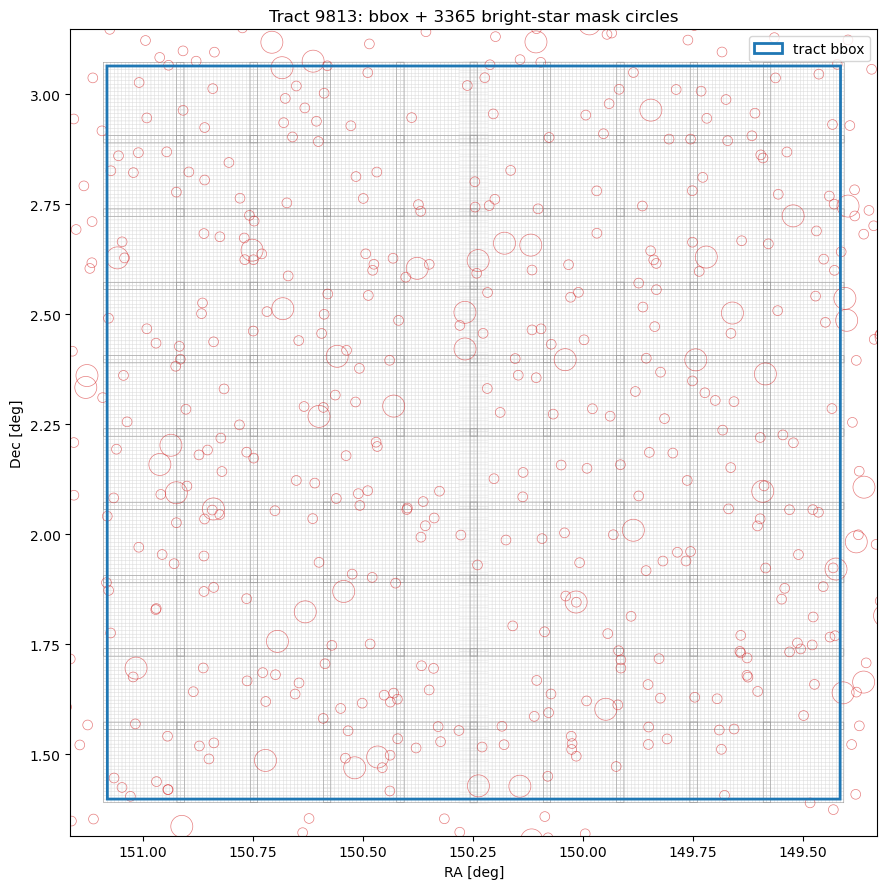

In [29]:
# Tract bbox -> sky polygon (unexpanded tract bbox corners).
poly_radec = bbox_to_radec(tractInfo.getBBox())

fig, ax = plt.subplots(figsize=(9, 9))

# Patch and cell boundaries, drawn in lighter lines underneath everything else.
for patchInfo in tractInfo:
    ax.add_patch(Polygon(bbox_to_radec(patchInfo.outer_bbox), closed=True,
                         fill=False, edgecolor="0.6", lw=0.4, zorder=1))
    # Cells (lsst_cells_v2): getCellInfo takes a sequential integer index.
    nc = patchInfo.getNumCells()   # Index2D(x, y)
    for i in range(nc.x * nc.y):
        cbbox = patchInfo.getCellInfo(i).outer_bbox
        ax.add_patch(Polygon(bbox_to_radec(cbbox), closed=True,
                             fill=False, edgecolor="0.85", lw=0.2, zorder=0))

# Tract boundary.
ax.add_patch(Polygon(poly_radec, closed=True, fill=False,
                     edgecolor="tab:blue", lw=2, label="tract bbox", zorder=3))

# One ellipse per circle; width scaled by 1/cos(dec) so it looks round in RA/Dec.
for circ in circles:
    center = LonLat(circ.getCenter())
    ra = center.getLon().asDegrees()
    dec = center.getLat().asDegrees()
    rad_deg = circ.getOpeningAngle().asDegrees()
    ax.add_patch(Ellipse((ra, dec),
                         width=2 * rad_deg / np.cos(np.radians(dec)),
                         height=2 * rad_deg,
                         fill=False, edgecolor="tab:red", lw=0.5, alpha=0.6, zorder=2))

# Axis limits slightly larger than the tract bbox.
ra_min, ra_max = poly_radec[:, 0].min(), poly_radec[:, 0].max()
dec_min, dec_max = poly_radec[:, 1].min(), poly_radec[:, 1].max()
pad_ra = 0.05 * (ra_max - ra_min)
pad_dec = 0.05 * (dec_max - dec_min)
# RA increases to the left, so set the inverted limits explicitly.
ax.set_xlim(ra_max + pad_ra, ra_min - pad_ra)
ax.set_ylim(dec_min - pad_dec, dec_max + pad_dec)

ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title(f"Tract {tractId}: bbox + {len(circles)} bright-star mask circles")
ax.set_aspect(1.0 / np.cos(np.radians(poly_radec[:, 1].mean())))
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [30]:
def iter_overlapping_cells(tractInfo, region):
    """Yield (patchId, cellId, overlap) for every cell whose outer sky polygon
    touches `region`. `overlap` is "full" if the cell lies entirely within the
    region, else "partial". patchId/cellId are sequential integer indices.

    Partial overlaps ARE reported (yielded with overlap="partial").
    """
    for patchInfo in tractInfo:
        # Prune whole patches that don't overlap.
        # We are being hopeful here.
        if patchInfo.inner_sky_polygon.isDisjointFrom(region):
            continue
        patchId = patchInfo.index
        # We loop over only the inner cells.
        for cx, cy in product(range(1, 22), range(1, 22)):
            cellId = Index2D(cx, cy)
            cellInfo = patchInfo.getCellInfo(cellId)
            poly = cellInfo.inner_sky_polygon
            if poly.isDisjointFrom(region):
                continue
            overlap = "full" if poly.isWithin(region) else "partial"
            yield patchId, cellId, overlap

In [31]:
overlaps = iter_overlapping_cells(tractInfo, union)

In [32]:
for num, row in enumerate(overlaps):
    print(row)
    if num > 20:
        break

(Index2D(x=0, y=0), Index2D(x=1, y=5), 'partial')
(Index2D(x=0, y=0), Index2D(x=1, y=6), 'partial')
(Index2D(x=0, y=0), Index2D(x=1, y=7), 'partial')
(Index2D(x=0, y=0), Index2D(x=2, y=5), 'partial')
(Index2D(x=0, y=0), Index2D(x=2, y=6), 'full')
(Index2D(x=0, y=0), Index2D(x=2, y=7), 'partial')
(Index2D(x=0, y=0), Index2D(x=2, y=8), 'partial')
(Index2D(x=0, y=0), Index2D(x=3, y=3), 'partial')
(Index2D(x=0, y=0), Index2D(x=3, y=4), 'partial')
(Index2D(x=0, y=0), Index2D(x=3, y=5), 'partial')
(Index2D(x=0, y=0), Index2D(x=3, y=6), 'partial')
(Index2D(x=0, y=0), Index2D(x=3, y=7), 'partial')
(Index2D(x=0, y=0), Index2D(x=3, y=8), 'partial')
(Index2D(x=0, y=0), Index2D(x=4, y=2), 'partial')
(Index2D(x=0, y=0), Index2D(x=4, y=3), 'partial')
(Index2D(x=0, y=0), Index2D(x=4, y=4), 'full')
(Index2D(x=0, y=0), Index2D(x=4, y=5), 'partial')
(Index2D(x=0, y=0), Index2D(x=4, y=6), 'partial')
(Index2D(x=0, y=0), Index2D(x=4, y=7), 'partial')
(Index2D(x=0, y=0), Index2D(x=5, y=1), 'partial')
(Index

In [33]:
# ReferenceObjectLoader.loadRegion accesses `dataId.region` as an *attribute*
# (dataId.region.intersects(region)), so region must be a property, not a method.
# the_monster is sharded on htm7, so each ref's region is its HTM level-7 trixel.
class MyDataCoordinate:
    _htm = HtmPixelization(7)

    def __init__(self, ref):
        self._htm7 = ref.dataId["htm7"]

    @property
    def region(self):
        return self._htm.pixel(self._htm7)


# One MyDataCoordinate per ref, in the same order as refCats so the loader's
# zip(self.dataIds, self.refCats) pairs each ref with its correct region.
dataIds = [MyDataCoordinate(ref) for ref in ref_cat_refs]

# loadRegion calls refCat.get(), so refCats must be *deferred* dataset handles,
# not bare DatasetRefs (which have no .get()).
refCats = [butler.getDeferred(ref) for ref in ref_cat_refs]

ref_loader = ReferenceObjectLoader(
    dataIds=dataIds,
    refCats=refCats,
    name="the_monster_20250219",
    config=ref_loader_config,
)
print(f"ref_loader built with {len(dataIds)} dataIds / {len(refCats)} refCats")
print("sample region:", type(dataIds[0].region).__name__)

ref_loader built with 96 dataIds / 96 refCats
sample region: ConvexPolygon


In [27]:
circles = []
for ref in ref_cat_refs:
    cat = butler.get(ref)
    ra = np.asarray(cat["coord_ra"])      # radians
    dec = np.asarray(cat["coord_dec"])    # radians
    flux = np.asarray(cat["phot_g_mean_flux"])  # nJy

    # Only positive, finite fluxes yield a valid magnitude.
    good = np.isfinite(flux) & (flux > 0)
    mag = np.full(len(cat), np.inf)
    mag[good] = -2.5 * np.log10(flux[good]) + AB_ZP_NJY

    radius = mag_to_radius(mag)  # opening angle in radians

    for i in np.where(radius > 0)[0]:
        center = UnitVector3d(LonLat.fromRadians(ra[i], dec[i]))
        circles.append(Circle(center, Angle(radius[i])))

print("Number of circles (radius > 0):", len(circles))
union = UnionRegion(*circles) if circles else UnionRegion()
print("Union region type:", type(union).__name__, "| n sub-regions:", len(circles))

Number of circles (radius > 0): 3365
Union region type: UnionRegion | n sub-regions: 3365


In [34]:
# Load reference objects over the tract, expanded by pixelMargin.
# loadPixelBox(bbox, wcs, filterName, ...) converts the pixel box to a sphere
# region internally and pulls every shard (via dataId.region) that overlaps.
loadBBox = lsst.geom.Box2I(tractInfo.getBBox())
loadBBox.grow(ref_loader_config.pixelMargin)

result = ref_loader.loadPixelBox(
    bbox=loadBBox,
    wcs=wcs,
    filterName="phot_g_mean",   # -> phot_g_mean_flux
)
refCat = result.refCat
print("fluxField:", result.fluxField)
print("n reference objects loaded:", len(refCat))

fluxField: phot_g_mean_flux
n reference objects loaded: 12200


In [35]:
# Radius per refCat row, from its phot_g_mean_flux -> AB mag -> mag_to_radius.
ra = np.asarray(refCat["coord_ra"])    # radians
dec = np.asarray(refCat["coord_dec"])  # radians
flux = np.asarray(refCat[result.fluxField])  # nJy

good = np.isfinite(flux) & (flux > 0)
mag = np.full(len(refCat), np.inf)
mag[good] = -2.5 * np.log10(flux[good]) + AB_ZP_NJY

radius = mag_to_radius(mag)  # opening angle in radians

circles_refcat = [
    Circle(UnitVector3d(LonLat.fromRadians(ra[i], dec[i])), Angle(radius[i]))
    for i in np.where(radius > 0)[0]
]
print("Number of circles (radius > 0):", len(circles_refcat))

Number of circles (radius > 0): 430


In [36]:
def plot_bright_star_masks(tractInfo, union):
    poly_radec = bbox_to_radec(tractInfo.getBBox())
    
    fig, ax = plt.subplots(figsize=(9, 9))
    
    # Patch and cell boundaries, lighter lines underneath.
    for patchInfo in tractInfo:
        ax.add_patch(Polygon(bbox_to_radec(patchInfo.outer_bbox), closed=True,
                             fill=False, edgecolor="0.6", lw=0.4, zorder=1))
        nc = patchInfo.getNumCells()
        for i in range(nc.x * nc.y):
            cbbox = patchInfo.getCellInfo(i).outer_bbox
            ax.add_patch(Polygon(bbox_to_radec(cbbox), closed=True,
                                 fill=False, edgecolor="0.85", lw=0.2, zorder=0))
    
    # Tract boundary.
    ax.add_patch(Polygon(poly_radec, closed=True, fill=False,
                         edgecolor="tab:blue", lw=2, label="tract bbox", zorder=3))
    
    # One ellipse per refCat circle; width scaled by 1/cos(dec) to look round.
    circles = union.getRegions(union)
    for circ in union.getRegions(union):
        center = LonLat(circ.getCenter())
        ra_c = center.getLon().asDegrees()
        dec_c = center.getLat().asDegrees()
        rad_deg = circ.getOpeningAngle().asDegrees()
        ax.add_patch(Ellipse((ra_c, dec_c),
                             width=2 * rad_deg / np.cos(np.radians(dec_c)),
                             height=2 * rad_deg,
                             fill=False, edgecolor="tab:red", lw=0.5, alpha=0.6, zorder=2))
    
    ra_min, ra_max = poly_radec[:, 0].min(), poly_radec[:, 0].max()
    dec_min, dec_max = poly_radec[:, 1].min(), poly_radec[:, 1].max()
    pad_ra = 0.1 * (ra_max - ra_min)
    pad_dec = 0.1 * (dec_max - dec_min)
    ax.set_xlim(ra_max + pad_ra, ra_min - pad_ra)  # RA increases to the left
    ax.set_ylim(dec_min - pad_dec, dec_max + pad_dec)
    
    ax.set_xlabel("RA [deg]")
    ax.set_ylabel("Dec [deg]")
    ax.set_title(f"Tract {tractId}: bbox + {len(circles)} mask circles")
    ax.set_aspect(1.0 / np.cos(np.radians(poly_radec[:, 1].mean())))
    plt.tight_layout()
    plt.show()

    return fig, ax

def bbox_to_radec(bbox):
    """Corners of a pixel Box2I/Box2D as an (N,2) array of (RA, Dec) in degrees."""
    return np.array(
        [[c.getLongitude().asDegrees(), c.getLatitude().asDegrees()]
         for c in (wcs.pixelToSky(p) for p in lsst.geom.Box2D(bbox).getCorners())]
    )